In [1]:
# TASK 3 - END-TO-END DATA SCIENCE PROJECT
# Intern: Vivek Dipak Kshirsagar | ID: CTIS6665
# Codtech IT Solutions | Data Science Internship

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ All Libraries Imported!")

✅ All Libraries Imported!


In [2]:
# STEP 2 - LOAD DATASET (Iris Dataset)

from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0:'setosa', 1:'versicolor', 2:'virginica'})

print("✅ Dataset Loaded!")
print(f"\nShape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nDataset Info:")
print(df.describe())

✅ Dataset Loaded!

Shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Dataset Info:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%            

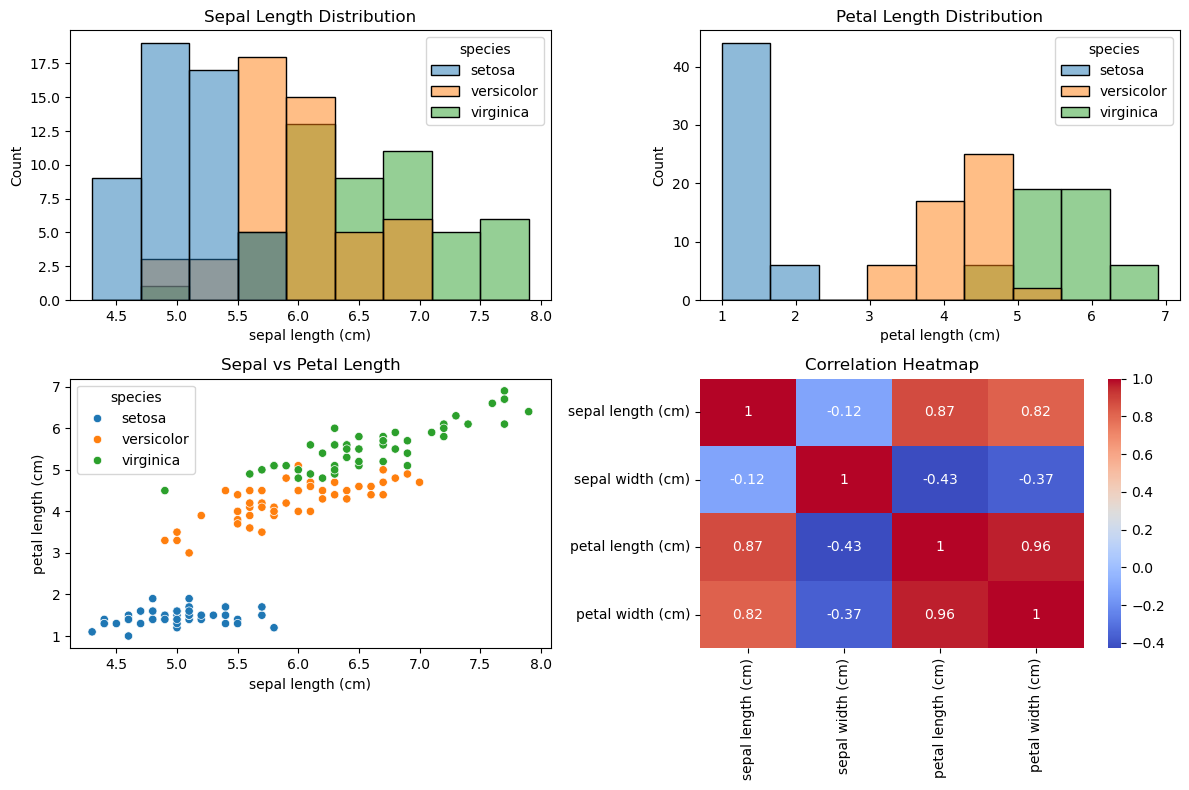

✅ EDA Visualizations Done!


In [3]:
# STEP 3 - EDA VISUALIZATIONS

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1
sns.histplot(data=df, x='sepal length (cm)', hue='species', ax=axes[0,0])
axes[0,0].set_title('Sepal Length Distribution')

# Plot 2
sns.histplot(data=df, x='petal length (cm)', hue='species', ax=axes[0,1])
axes[0,1].set_title('Petal Length Distribution')

# Plot 3
sns.scatterplot(data=df, x='sepal length (cm)', y='petal length (cm)', 
                hue='species', ax=axes[1,0])
axes[1,0].set_title('Sepal vs Petal Length')

# Plot 4
sns.heatmap(df.drop(['target','species'], axis=1).corr(), 
            annot=True, cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('task3_eda.png')
plt.show()
print("✅ EDA Visualizations Done!")

In [4]:
# STEP 4 - MODEL TRAINING

X = df.drop(['target', 'species'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print("✅ Model Trained!")
print(f"\nAccuracy: {acc * 100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=iris.target_names))

✅ Model Trained!

Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



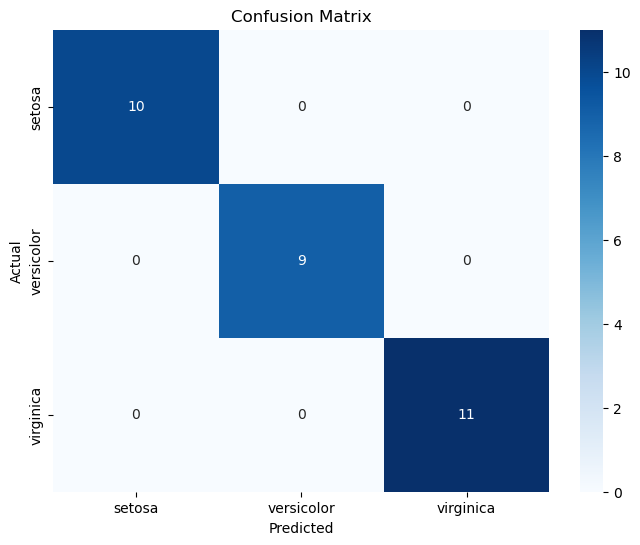

✅ Confusion Matrix Done!


In [5]:
# STEP 5 - CONFUSION MATRIX

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('task3_confusion.png')
plt.show()
print("✅ Confusion Matrix Done!")

In [6]:
# STEP 6 - SAVE MODEL

pickle.dump(model, open('iris_model.pkl', 'wb'))
pickle.dump(scaler, open('iris_scaler.pkl', 'wb'))
print("✅ Model Saved!")

✅ Model Saved!


In [7]:
# STEP 7 - FLASK APP CODE

flask_code = '''
from flask import Flask, request, jsonify
import pickle
import numpy as np

app = Flask(__name__)

model = pickle.load(open('iris_model.pkl', 'rb'))
scaler = pickle.load(open('iris_scaler.pkl', 'rb'))

@app.route('/')
def home():
    return "Iris Flower Prediction API is Running!"

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json
    features = np.array([[
        data['sepal_length'],
        data['sepal_width'],
        data['petal_length'],
        data['petal_width']
    ]])
    scaled = scaler.transform(features)
    prediction = model.predict(scaled)[0]
    species = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
    return jsonify({'prediction': species[prediction]})

if __name__ == '__main__':
    app.run(debug=True)
'''

with open('app.py', 'w') as f:
    f.write(flask_code)

print("✅ Flask App Code Saved as app.py!")
print("\n" + "="*50)
print("TASK 3 - END-TO-END PROJECT COMPLETE!")
print("="*50)
print(f"Dataset: Iris Flower Dataset")
print(f"Model: Logistic Regression")
print(f"Accuracy: {acc * 100:.2f}%")
print("Deployment: Flask API Ready!")
print("Intern: Vivek Dipak Kshirsagar | CTIS6665")
print("="*50)

✅ Flask App Code Saved as app.py!

TASK 3 - END-TO-END PROJECT COMPLETE!
Dataset: Iris Flower Dataset
Model: Logistic Regression
Accuracy: 100.00%
Deployment: Flask API Ready!
Intern: Vivek Dipak Kshirsagar | CTIS6665
